In [3]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec

In [4]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [5]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [6]:
# # get names of all images in dataset_dir/images
# image_names = os.listdir(f"{DATASET_DIR}/images")

# count_images = len(image_names)

In [7]:
# count_images

In [8]:
# # sort image names based on number in name name format is : image_number.png
# image_names.sort(key=lambda x: int(x.split(".")[0].split("_")[1]))

In [9]:
# image_names[-5:]

In [10]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [11]:
# data["Label"].value_counts()

In [12]:
# data.tail()

In [13]:
# train_data = data.groupby("Label").sample(5000, random_state=42)
# train_data.head()

In [14]:
# train_data_index = train_data.index
# train_data_index

In [15]:
# remaining_data = data[~data.index.isin(train_data_index)]
# remaining_data.head()

In [16]:
# remaining_data["Label"].value_counts()

In [17]:
# # get data for validation and test
# # test data size should be 10k
# val_data = remaining_data.groupby("Label").sample(5000, random_state=42)

# val_data_index = val_data.index

# val_data["Label"].value_counts()

In [18]:
# test_data = remaining_data[~remaining_data.index.isin(val_data_index)]

# test_data["Label"].value_counts()

In [19]:
# def clean_image_path(image_path):
#     return os.path.basename(image_path)

# # store images and labels in a dataframe
# def store_images_and_labels(data_index, bin_labels, datatype):
#     images = []
#     labels = []

#     images_dir = f"{DATASET_DIR}/images"

#     for index in data_index:
#         image_path = f"{images_dir}/image_{index}.png"
#         images.append(image_path)
#         labels.append(bin_labels[index])

#     df = pd.DataFrame({
#         "Image": images,
#         "Label": labels
#     })


#     df["Image"] = df["Image"].apply(clean_image_path)

#     df.to_csv(f"{DATASET_DIR}/{datatype}.csv", index=False)

#     return df

# # images = []
# # labels = []

# # images_dir = f"{DATASET_DIR}/images"

# # with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
# #     all_labels = pickle.load(f)

# # for index in train_data_index:
# #     # images are grayscale, with mode L
# #     image_path = f"{images_dir}/image_{index}.png"
# #     images.append(image_path)
# #     labels.append(all_labels[index])


# # train_df = pd.DataFrame({
# #     "Image": images,
# #     "Label": labels
# # })


# with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
#     all_labels = pickle.load(f)

# data_labels = data["Label"]

# train_df = store_images_and_labels(train_data_index, data_labels, "train_multi")

In [20]:
# val_df = store_images_and_labels(val_data_index, data_labels, "val_multi")
# test_df = store_images_and_labels(test_data.index, data_labels, "test_multi")

In [21]:
train_df = pd.read_csv(f"{DATASET_DIR}/train_multi.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val_multi.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test_multi.csv")

In [22]:
train_df["Label"].value_counts()

Label
Benign          5000
Botnet          5000
Brute Force     5000
DDoS            5000
DoS             5000
Infiltration    5000
Name: count, dtype: int64

In [23]:
# verify the images in train are not in val or test
train_images = set(train_df["Image"])
val_images = set(val_df["Image"])
test_images = set(test_df["Image"])

assert len(train_images.intersection(val_images)) == 0
assert len(train_images.intersection(test_images)) == 0

# verify the images in val are not in test
assert len(val_images.intersection(test_images)) == 0

In [24]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [25]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

# LE.classes_

# swap classes in the label encoder
# swapped_classes = LE.classes_.copy()
# swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

# LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,0
1,image_2975672.png,0
2,image_6489183.png,0
3,image_2675390.png,0
4,image_5559062.png,0


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # transforms.RandomHorizontalFlip(),  # randomly flip images horizontally
    # transforms.RandomRotation(10),      # slight random rotation
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # random translation
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

# Keep validation transforms simple - just basic preprocessing
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=train_transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=val_transform)

In [ ]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

# sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
sample_weights

array([0.0002, 0.0002, 0.0002, ..., 0.0002, 0.0002, 0.0002])

In [28]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
class BinaryCNN2(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN2, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
            
        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 2 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
            # nn.ReLU(),
            # nn.Dropout(0.2),

            # nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

class BinaryCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding="same"),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
            
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class BinaryCNN3(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN3, self).__init__()
        
        # Feature extraction layers
        self.conv1 = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
        )

        self.conv2 = nn.Sequential(
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        # print(x.shape)
        x = self.conv2(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

In [30]:
# dummy = torch.randn(1, 1, 32, 32)
# model = BinaryCNN()
# model(dummy)

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_sigmoid = nn.BCELoss
criterion_logits = nn.BCEWithLogitsLoss
criterion_cross_entropy = nn.CrossEntropyLoss

In [48]:
# calculate metrics for binary classification
# accuracy, precision, recall, f1 score
# use sklearn to calculate these metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="micro")
    recall = recall_score(y_true, y_pred, average="micro")
    f1 = f1_score(y_true, y_pred, average="micro")
    
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def calculate_class_metrics(y_true, y_pred):
    """Calculate metrics for each class separately."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


    overall_accuracy = accuracy_score(y_true, y_pred)

    benign_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0
    malicious_accuracy = tn / (tn + fp) if (tn + fp) > 0 else 0

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'overall_accuracy': overall_accuracy,
        'benign': {
            'accuracy': benign_accuracy,
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'accuracy': malicious_accuracy,
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [33]:
# # def train_model(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, model_savepath=None, weight_decay=0.0):
#     model = model_class().to(device)
#     criterion = loss_class(pos_weight=weights) if weights else loss_class()
#     optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

#     best_val_loss = np.inf
#     best_epoch = 0
#     best_model = None
#     early_stop_counter = 0

#     history = {
#         "train_loss": [], "val_loss": [],
#         "benign_metrics": {
#             "train": {"precision": [], "recall": [], "f1": []},
#             "val": {"precision": [], "recall": [], "f1": []}
#         },
#         "malicious_metrics": {
#             "train": {"precision": [], "recall": [], "f1": []},
#             "val": {"precision": [], "recall": [], "f1": []}
#         }
#     }

#     for epoch in range(num_epochs):
#         print(f"\nEpoch {epoch+1}/{num_epochs}")
#         print("-" * 50)

#         # Training phase
#         model.train()
#         train_loss = 0.0
#         train_preds = []
#         train_true = []

#         for images, labels in tqdm(train_dataloader, desc="Training Batches"):
#             images, labels = images.to(device), labels.float().to(device)
            
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels.view(-1, 1))
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
#             preds = (torch.sigmoid(outputs) > 0.5).flatten().detach().cpu().numpy()
#             true = labels.squeeze().detach().cpu().numpy()

#             train_preds.extend(preds)
#             train_true.extend(true)

#         train_loss /= len(train_dataloader.dataset)
#         train_metrics = calculate_class_metrics(train_true, train_preds)

#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_preds = []
#         val_true = []

#         with torch.no_grad():
#             for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
#                 images, labels = images.to(device), labels.float().to(device)
                
#                 outputs = model(images)
#                 loss = criterion(outputs, labels.view(-1, 1))
#                 val_loss += loss.item()
                
#                 preds = (torch.sigmoid(outputs) > 0.5).flatten().detach().cpu().numpy()
#                 true = labels.squeeze().detach().cpu().numpy()

#                 val_preds.extend(preds)
#                 val_true.extend(true)

#         val_loss /= len(val_dataloader.dataset)
#         val_metrics = calculate_class_metrics(val_true, val_preds)

#         # Update history
#         history["train_loss"].append(train_loss)
#         history["val_loss"].append(val_loss)
        
#         for metric in ["precision", "recall", "f1"]:
#             history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
#             history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
#             history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
#             history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

#         # Print metrics
#         print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
#         print("\nBenign Metrics:")
#         print(f"Train - Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
#         print(f"Val - Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
#         print("\nMalicious Metrics:")
#         print(f"Train - Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
#         print(f"Val - Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")

#         # Early stopping
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_epoch = epoch
#             best_model = model.state_dict()
#             if model_savepath:
#                 torch.save(model.state_dict(), model_savepath)
#             early_stop_counter = 0
#         else:
#             early_stop_counter += 1
#             if early_stop_counter >= early_stop:
#                 print(f"\nEarly stopping at epoch {epoch+1}")
#                 break

#         scheduler.step(val_loss)

#     return best_model, history

In [ ]:
def train_model_reduceonplateau(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class(num_classes=6).to(device)
    
    if pos_weights is not None:
        criterion = loss_class(pos_weight=pos_weights)
    elif weights is not None:
        criterion = loss_class(weight=weights)
    else:
        criterion = loss_class()


    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_accuracy": [],
        "val_accuracy": [],
        "train_precision": [],
        "val_precision": [],
        "train_recall": [],
        "val_recall": [],
        "train_f1": [],
        "val_f1": [],
        "train_loss": [],
        "val_loss": [],
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []  # Added to store probabilities

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)
            
            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if loss_class == nn.CrossEntropyLoss:
                probs = outputs.detach().cpu().numpy()
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = np.argmax(probs, axis=1)  # Get predictions


            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)  # Store probabilities

        train_loss /= len(train_dataloader)
        train_metrics = calculate_metrics(train_true, train_preds)

        # Validation phase
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []  # Added to store probabilities

        with torch.no_grad():
            model.eval()


            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                if loss_class == nn.CrossEntropyLoss:
                    probs = outputs.detach().cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = np.argmax(probs, axis=1)

                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)  # Store probabilities

        val_loss /= len(val_dataloader)
        val_metrics = calculate_metrics(val_true, val_preds)
        

        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history[f"train_{metric}"].append(train_metrics[metric])
            history[f"val_{metric}"].append(val_metrics[metric])

        if debug:
            # Print metrics
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['accuracy']:.4f}, Val: {val_metrics['accuracy']:.4f}")
            print(f"Precision - Train: {train_metrics['precision']:.4f}, Val: {val_metrics['precision']:.4f}")
            print(f"Recall - Train: {train_metrics['recall']:.4f}, Val: {val_metrics['recall']:.4f}")
            print(f"F1 - Train: {train_metrics['f1']:.4f}, Val: {val_metrics['f1']:.4f}")
        else:
            # Print loss and overall accuracy
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['accuracy']:.4f}, Val: {val_metrics['accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            if model_savepath:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': best_val_loss,
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        scheduler.step(val_loss)

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [ ]:
def train_model_cosine(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)

    if pos_weights is not None:
        criterion = loss_class(pos_weight=pos_weights)
    elif weights is not None:
        criterion = loss_class(weight=weights)
    else:
        criterion = loss_class()


    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # CosineAnnealingWarmRestarts scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=num_epochs // 10,
        T_mult=2,
        eta_min=1e-6
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "train_loss": [],
        "val_loss": [],
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)

            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            scheduler.step()

            train_loss += loss.item()



            if loss_class == nn.CrossEntropyLoss:
                probs = outputs.detach().cpu().numpy()
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = np.argmax(probs, axis=1)

            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)

        train_loss /= len(train_dataloader)
        train_metrics = calculate_metrics(train_true, train_preds)

        # Validation phase
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []

        with torch.no_grad():
            model.eval()

            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                
                if loss_class == nn.CrossEntropyLoss:
                    probs = outputs.detach().cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = np.argmax(probs, axis=1)

                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)

        val_loss /= len(val_dataloader)
        val_metrics = calculate_metrics(val_true, val_preds)
        
        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history[metric].append(val_metrics[metric])

        if debug:
            # Print metrics
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['accuracy']:.4f}, Val: {val_metrics['accuracy']:.4f}")
            print(f"Precision - Train: {train_metrics['precision']:.4f}, Val: {val_metrics['precision']:.4f}")
            print(f"Recall - Train: {train_metrics['recall']:.4f}, Val: {val_metrics['recall']:.4f}")
            print(f"F1 - Train: {train_metrics['f1']:.4f}, Val: {val_metrics['f1']:.4f}")

        else:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['accuracy']:.4f}, Val: {val_metrics['accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            # best_threshold = epoch_best_threshold  # Save the best threshold from this epoch
            if model_savepath:
                torch.save(model.state_dict(), model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [55]:
# def plot_metrics(history):
#     fig, ax = plt.subplots(2, 2, figsize=(12, 12))

#     ax[0, 0].plot(history["train_loss"], label="Train Loss")
#     ax[0, 0].plot(history["val_loss"], label="Val Loss")
#     ax[0, 0].set_title("Loss")
#     ax[0, 0].legend()

#     ax[0, 1].plot(history["train_accuracy"], label="Train Accuracy")
#     ax[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
#     ax[0, 1].set_title("Accuracy")
#     ax[0, 1].legend()

#     ax[1, 0].plot(history["train_precision"], label="Train Precision")
#     ax[1, 0].plot(history["val_precision"], label="Val Precision")
#     ax[1, 0].set_title("Precision")
#     ax[1, 0].legend()

#     ax[1, 1].plot(history["train_recall"], label="Train Recall")
#     ax[1, 1].plot(history["val_recall"], label="Val Recall")
#     ax[1, 1].set_title("Recall")
#     ax[1, 1].legend()

#     plt.show()

def plot_metrics(history):
    gs = GridSpec(3, 2)
    fig = plt.figure(figsize=(12, 12))

    ax = [
        [fig.add_subplot(gs[0, :])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
        [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[
            2, 1])]
    ]

    # Loss
    ax[0][0].plot(history["train_loss"], label="Train Loss")
    ax[0][0].plot(history["val_loss"], label="Val Loss")
    ax[0][0].set_title("Loss")
    ax[0][0].legend()


    # Accuracy
    ax[1][0].plot(history["train_accuracy"], label="Train Accuracy")
    ax[1][0].plot(history["val_accuracy"], label="Val Accuracy")
    ax[1][0].set_title("Accuracy")
    ax[1][0].legend()

    # Precision
    ax[1][1].plot(history["train_precision"], label="Train Precision")
    ax[1][1].plot(history["val_precision"], label="Val Precision")
    ax[1][1].set_title("Precision")
    ax[1][1].legend()

    # Recall
    ax[2][0].plot(history["train_recall"], label="Train Recall")
    ax[2][0].plot(history["val_recall"], label="Val Recall")
    ax[2][0].set_title("Recall")
    ax[2][0].legend()


    # F1
    ax[2][1].plot(history["train_f1"], label="Train F1")
    ax[2][1].plot(history["val_f1"], label="Val F1")
    ax[2][1].set_title("F1")
    ax[2][1].legend()


    plt.tight_layout()
    plt.show()


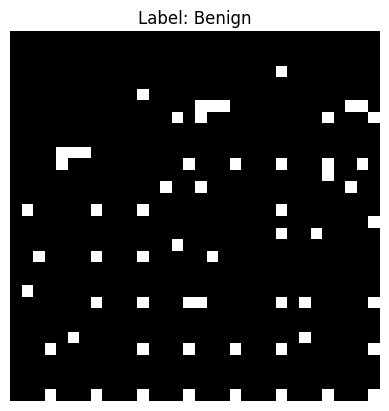

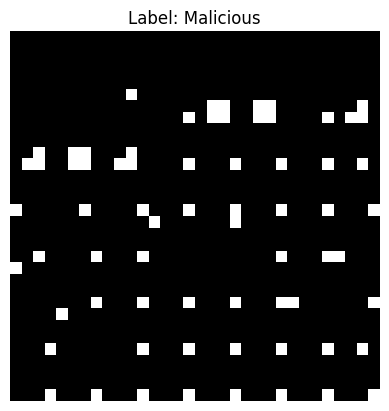

In [44]:
# plot a benign image
def plot_image(image, label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()


benign_image = train_dataset[0][0]
plot_image(benign_image, "Benign")

malicious_image = train_dataset[-1][0]
plot_image(malicious_image, "Malicious")

In [45]:
# computer class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])
class_weights

array([1., 1., 1., 1., 1., 1.])

In [52]:
model_savepath = f"../models/checkpoints/"

pathname_map = {
    'BinaryCNN': "bcnn",
    'BinaryCNN3': "bcnn3",
    'BinaryCNN2': "bcnn2"
}


benign_count = train_df_encoded["Label"].value_counts()[1]
malicious_count = train_df_encoded["Label"].value_counts().sum() - benign_count

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

pos_weight, class_weights

(tensor([5.], device='cuda:0'),
 tensor([1., 1., 1., 1., 1., 1.], device='cuda:0'))

In [53]:
best_stats = {
    "bcnn" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn2" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn3" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    }
}


for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__

    model_savepath_cosine = f"{model_savepath}{pathname_map[model_name]}_crossentropy_multi.pth"
    model_savepath_plateau = f"{model_savepath}{pathname_map[model_name]}_crossentropy_multi.pth"

    # print(f"Training {model_name} with CosineAnnealingWarmRestarts")
    # best_model_cos, history_cos = train_model_cosine(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=10, device=device, weights=class_weights, model_savepath=model_savepath_cosine, debug=False)
    # best_stats[pathname_map[model_name]]["cos"]["model"] = best_model_cos
    # best_stats[pathname_map[model_name]]["cos"]["history"] = history_cos
    # best_stats[pathname_map[model_name]]["cos"]["threshold"] = threshold_cos

    print(f"Training {model_name} with ReduceLROnPlateau")
    best_model_plateau, history_plateau = train_model_reduceonplateau(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, model_savepath=model_savepath_plateau, debug=False)
    best_stats[pathname_map[model_name]]["plateau"]["model"] = best_model_plateau
    best_stats[pathname_map[model_name]]["plateau"]["history"] = history_plateau
    # best_stats[pathname_map[model_name]]["plateau"]["threshold"] = threshold_plateau
    print("\n\n")

Training BinaryCNN with ReduceLROnPlateau

Epoch 1/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:26<00:00, 27.85it/s]



Loss - Train: 0.0106, Val: 0.0055
Accuracy - Train: 0.8118, Val: 0.8962

Epoch 2/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:26<00:00, 28.73it/s]



Loss - Train: 0.0062, Val: 0.0052
Accuracy - Train: 0.8815, Val: 0.8953

Epoch 3/50
--------------------------------------------------


...


Loss - Train: 0.0039, Val: 0.0042
Accuracy - Train: 0.9235, Val: 0.9185

Epoch 49/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:27<00:00, 27.66it/s]



Loss - Train: 0.0038, Val: 0.0042
Accuracy - Train: 0.9233, Val: 0.9185

Epoch 50/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:26<00:00, 27.93it/s]



Loss - Train: 0.0039, Val: 0.0042
Accuracy - Train: 0.9221, Val: 0.9185

Best model was from epoch 35 with validation loss 0.0041





Model: bcnn
ReduceLROnPlateau


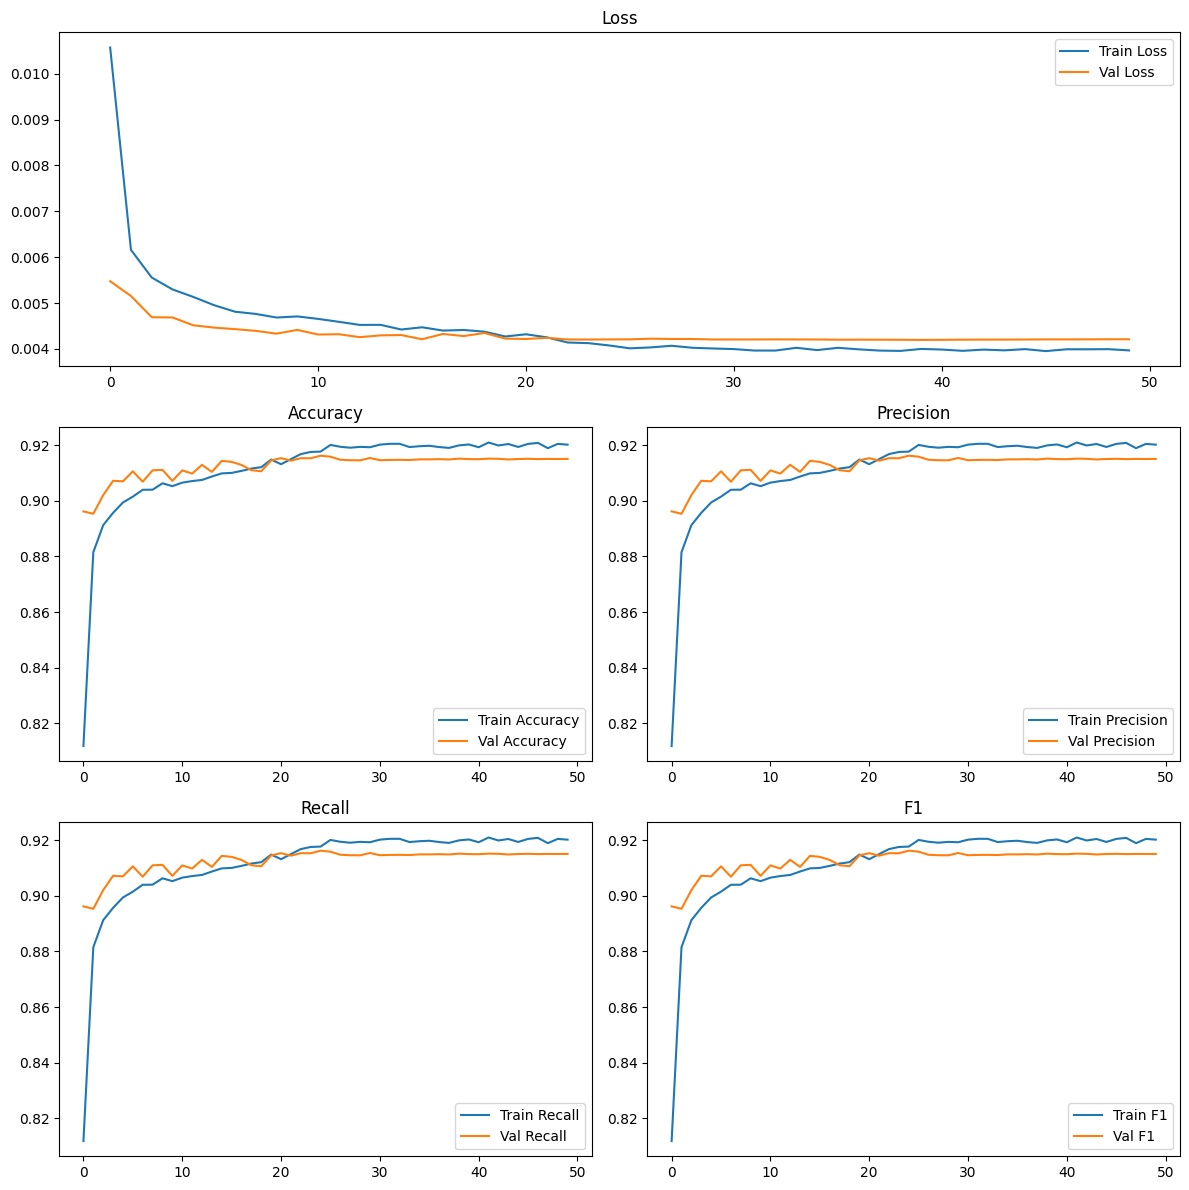




Model: bcnn2
ReduceLROnPlateau


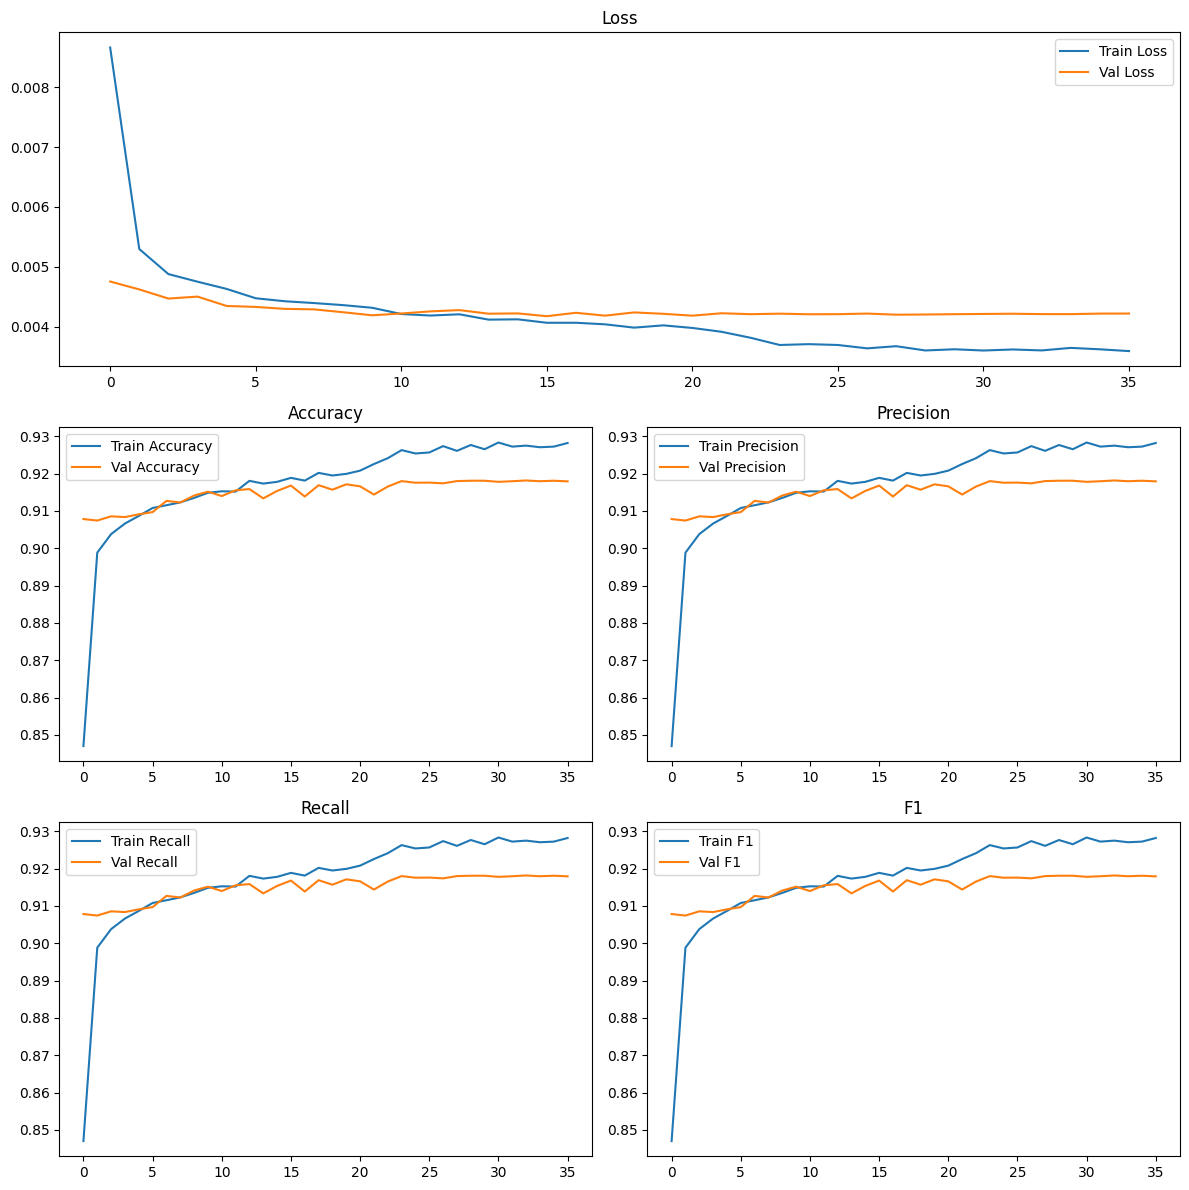




Model: bcnn3
ReduceLROnPlateau


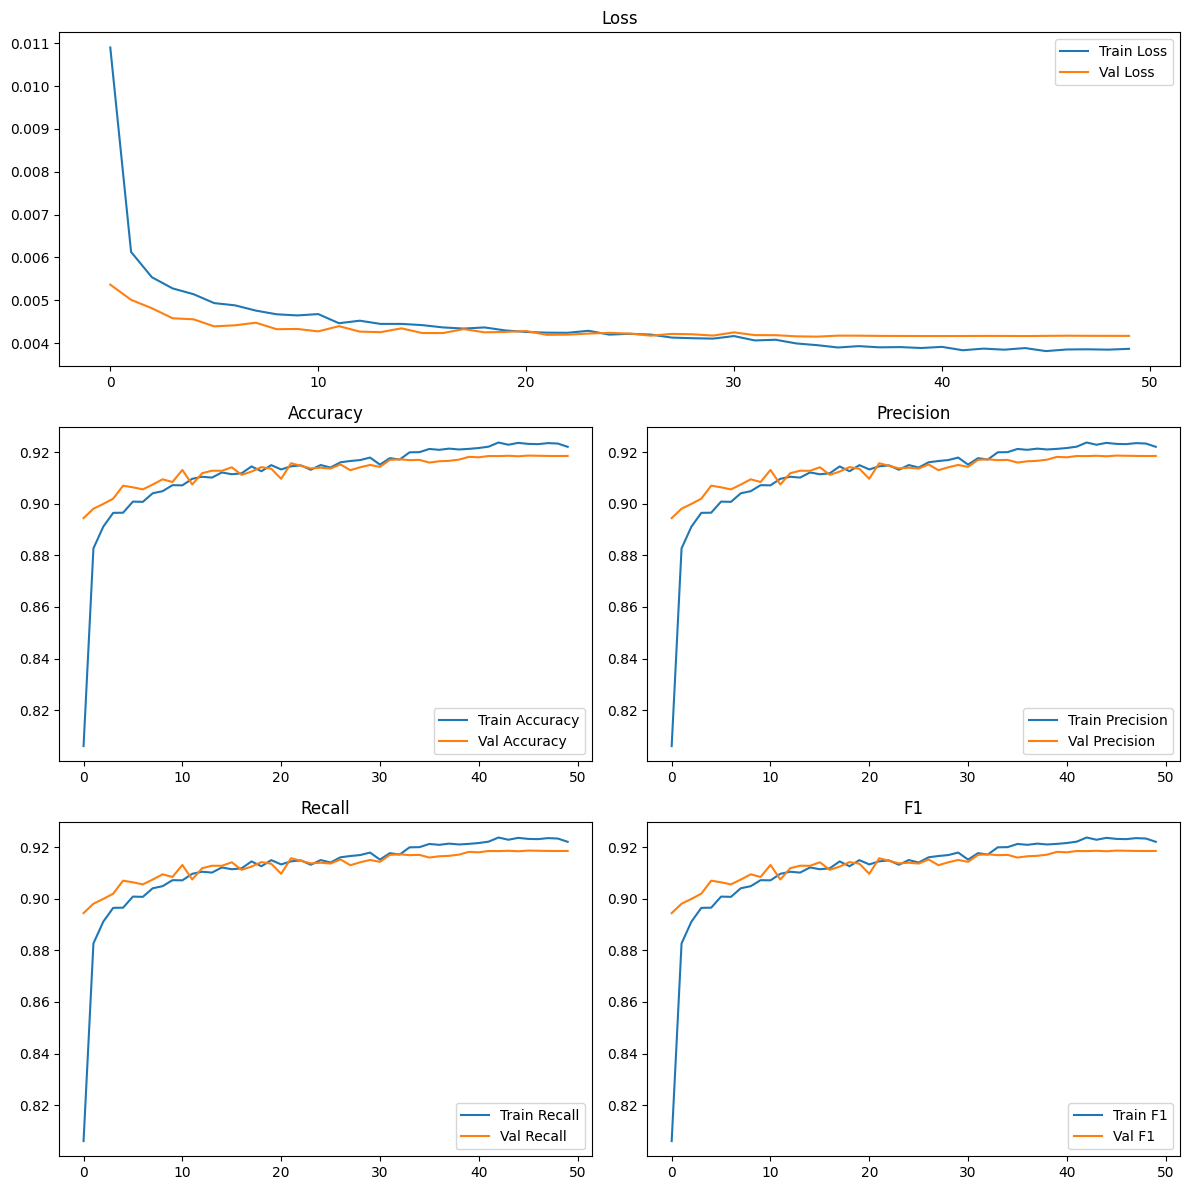

In [56]:
# plot metrics for each model
for model_name, model_stats in best_stats.items():
    print(f"Model: {model_name}")
    print("ReduceLROnPlateau")
    plot_metrics(model_stats["plateau"]["history"])
    print("\n\n")

In [57]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

In [58]:
test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [80]:
from sklearn.metrics import confusion_matrix

def test_model(model, test_dataset, device="cuda"):
    
    preds = []
    true = []

    with torch.no_grad():
        model.eval()
        
        for i, (images, labels) in tqdm(enumerate(test_dataset), desc=f"Testing Batches"):
            images, labels = images.to(device), labels.float().to(device)

            outputs = model(images)
            # probs = torch.sigmoid(outputs).detach().cpu().numpy()
            preds.extend(torch.argmax(outputs, dim=1).detach().cpu().numpy())
            true.extend(labels.squeeze().detach().cpu().numpy())

    return true, preds

def test_metrics(true, preds):
    metrics = calculate_metrics(true, preds)

    accuracy = metrics["accuracy"]
    precision = metrics["precision"]
    recall = metrics["recall"]
    f1 = metrics["f1"]

    
    # confusion matrix
    cm = confusion_matrix(true, preds)

    # plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")

    plt.colorbar()

    # 1 is benign, 0 is malicious in predictions and labels

    tick_marks = np.arange(len(LE.classes_))
    plt.xticks(tick_marks, LE.classes_)
    plt.yticks(tick_marks, LE.classes_)
    plt.tight_layout()


    for i in range(len(LE.classes_)):
        for j in range(len(LE.classes_)):
            plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")



    plt.show()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1


In [ ]:
# sample 12000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(2000, random_state=42)


test_data_sample["Label"].value_counts()

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

Testing BinaryCNN with ReduceLROnPlateau


Testing Batches: 250it [00:09, 25.75it/s]


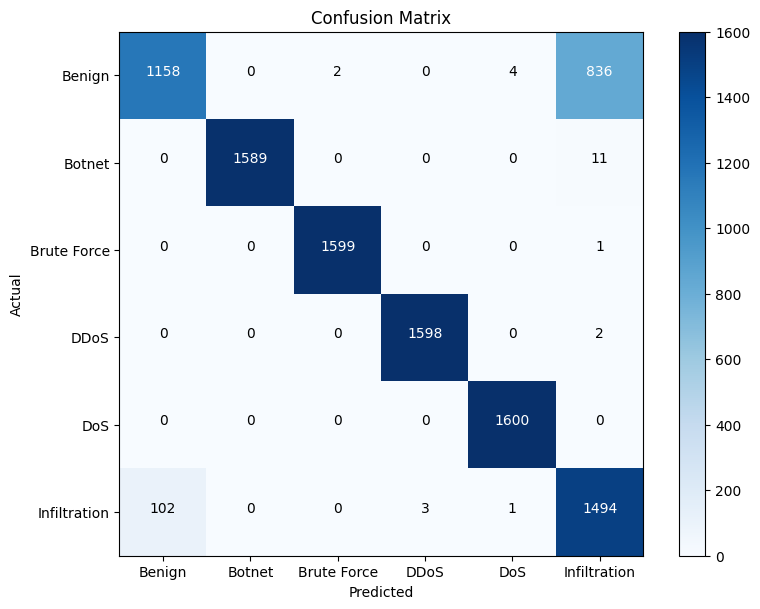

Accuracy: 0.9038
Precision: 0.9038
Recall: 0.9038
F1 Score: 0.9038



Testing BinaryCNN2 with ReduceLROnPlateau


Testing Batches: 250it [00:08, 29.31it/s]


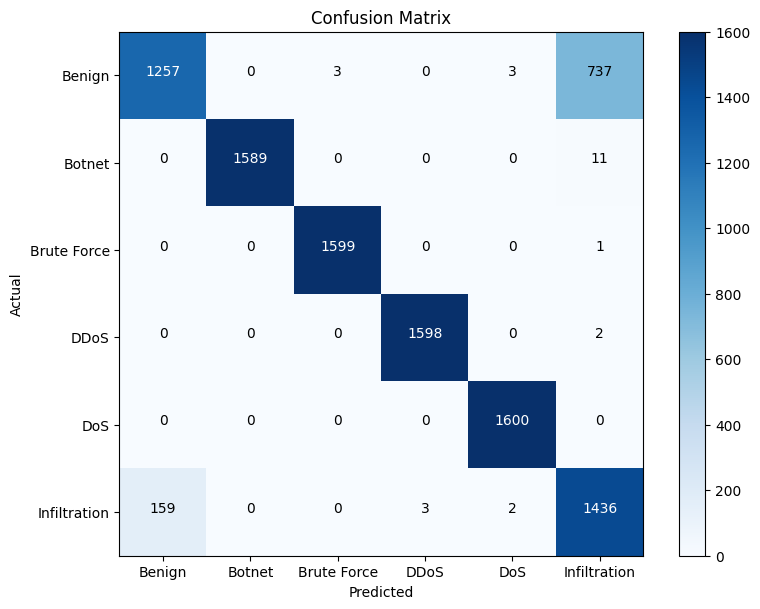

Accuracy: 0.9079
Precision: 0.9079
Recall: 0.9079
F1 Score: 0.9079



Testing BinaryCNN3 with ReduceLROnPlateau


Testing Batches: 250it [00:07, 35.19it/s]


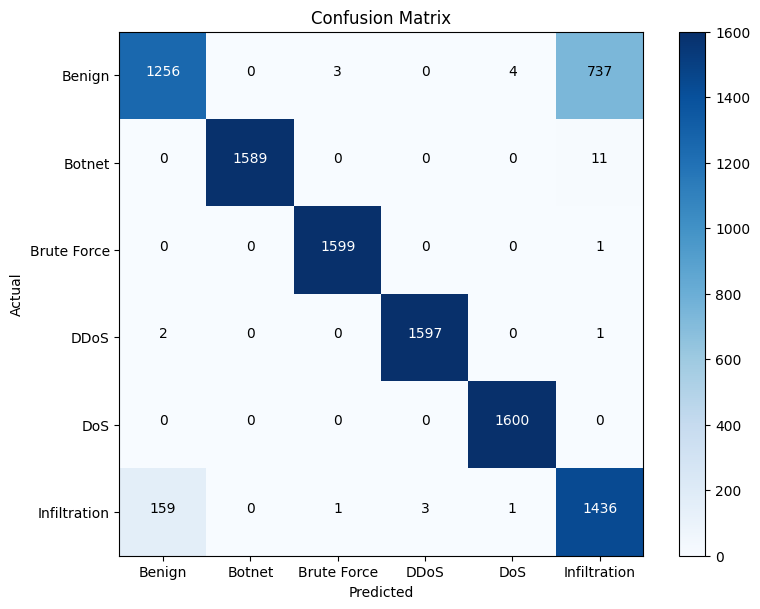

Accuracy: 0.9077
Precision: 0.9077
Recall: 0.9077
F1 Score: 0.9077





In [84]:
# model = BinaryCNN2().to(device)
# model.load_state_dict(torch.load(model_savepath, weights_only=True))


# test each model with the test data
# load model from checkpoint
# calculate metrics for each model

for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__
    # print(f"Testing {model_name} with CosineAnnealingWarmRestarts")
    # model = model_class().to(device)
    # model.load_state_dict(best_stats[pathname_map[model_name]]["cos"]["model"])
    # true, preds = test_model(model, test_data_loader_sample, device, threshold=best_stats[pathname_map[model_name]]["cos"]["threshold"])
    # test_metrics(true, preds)
    # print("\n\n")

    print(f"Testing {model_name} with ReduceLROnPlateau")
    model = model_class(num_classes=6).to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["plateau"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device)
    test_metrics(true, preds)
    print("\n\n")
